# AI 활용에 관하여

과제는 AI 를 사용할 것을 전제로 만들어지고 있습니다.
하지만, 학습의 효율성을 위해서 무분별한 AI 사용은 권장드리지 않고 있어요.

따라서, AI 를 피어리뷰어로서 생각하고 사용해주시는 것을 권고드립니다.  
이를 판단할 수 있는 하나의 기준으로는 같은 수업을 듣는 다른 친구에게 물어볼 수 있는 질문인가? 라고 스스로 물어보는 것도 좋은 기준이 될 수 있을 것 같습니다.

아래는 이에 대한 몇가지 예시입니다.


> AI 사용 가능:
> - 문법 및 API 확인
> - 오류 메시지 해석
> - 실행 환경 문제 해결
> - 내가 작성한 설명의 반례 요청

> AI에 맡기지 않을 것:
> - 실행 전 예측
> - 실행 결과에서 근거 선택
> - 의견 및 선택의 최종 판단

# 2주차 과제: 학습과 최적화

스터디에서 **학습은 모델이 더 적절한 추론을 하도록 가중치를 조절하는 작업**이라고 이야기했습니다.  
이번 과제에서는 그림으로 Gradient Descent를 이해하고, 작은 함수의 가중치를 직접 업데이트한 뒤 Fashion-MNIST에서 optimizer를 사용해봅니다.  

**필수 과정에서는 편미분이나 Chain Rule을 계산하지 않습니다.** Keras Layer 구현(Q13~Q14)과 맨 뒤의 편미분, 역전파 심화과제는 선택입니다.  
필수 코드 셀은 위에서부터 순서대로 실행하고, 채점머신 셀은 수정하지 않습니다.

처음에는 용어가 낯설 수 있습니다. “예측 → 오차 확인 → 가중치 조절 → 반복”이라는 흐름을 떠올리며 진행해주세요.

## 목차

1. **[스터디 내용 복습하기](#section-1-review)** - 학습, Cost Function, optimizer 등 핵심 개념 복습
2. **[그림으로 이해하는 Gradient Descent](#section-2-gradient-descent)** - gradient의 이동 방향과 learning rate 이해
3. **[작은 함수의 학습 과정 직접 구현하기](#section-3-implementation)** - Cost Function, parameter update와 batch 학습 구현
4. **[Fashion-MNIST에서 Optimizer 사용하기](#section-4-fashion-mnist)** - optimizer의 차이와 hyperparameter 확인
5. **[Keras가 학습을 처리하는 방식](#section-5-keras)** - 자동미분과 optimizer의 역할 이해

- **[선택 심화: 편미분과 역전파](#advanced)**
  - **[심화 A. 미분에서 편미분으로](#advanced-a)** - 편미분과 모델 parameter의 변화율
  - **[심화 B. 계산 그래프와 역전파](#advanced-b)** - 계산 그래프와 Gradient 전달 과정
  - **[심화 C. Gradient 구현하기](#advanced-c)** - MSE Gradient 직접 구현과 수치미분 검증

## 실행 환경과 재현성

- week1과 동일한 Python, NumPy, TensorFlow, Matplotlib 환경을 사용합니다.
- Fashion-MNIST는 Keras가 제공하는 데이터셋을 사용합니다.
- 같은 실행 결과를 확인할 수 있도록 seed를 고정합니다.
- Fashion-MNIST 를 다루며 optimizer를 코드에 연결하는 방법을 확인해봅니다.

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

<a id="section-1-review"></a>
# 1. 스터디 내용 복습하기

코드를 작성하기 전에 이번 주차의 핵심 개념을 정리해봅시다.

**Q1. 스터디에서는 학습을 ‘모델이 더 적절한 추론을 하도록 가중치를 조절하는 작업’이라고 정리했습니다.**  
모델을 $f_\theta(x)$라는 함수로 보았을 때 무엇이 바뀌는지 설명하고, 학습되는 parameter와 학습 전에 설정하는 hyperparameter의 차이도 함께 적어주세요.

**>>> $\theta$ 를 바꾸어나감. $\theta$는 가중치 전체를 의미함. 학습되는 파라미터는 가중치, 편향 등이고, hyperparameter는 학습을 시작하기 전 개발자가 직접 설정하는 값이다.<<<**

**Q2. 스터디에서는 Cost Function을 ‘추론이 얼마나 적절한지 수치화한 것’이라고 설명했습니다.**  
이 값이 모델의 학습에 있어서 어떻게 활용되나요? 또한 다른 Cost Function 은 언제 활용할 수 있을까요?  

**>>> Cost Function이 더 낮아지도록 모델을 조정함. <<<**

**Q3. Fashion-MNIST 는 주어진 이미지를 바탕으로 어떤 패션 아이템인지 구분하는 문제입니다.**  
따라서 출력값은 아이템 Index 에 해당하는 정수값입니다. 그렇다면, Cost Function 을 다음과 같이 정의하면 어떤 문제가 생길까요?  
Cost Function: 모델이 출력한 Index 와 정답 Index 를 비교합니다. 동일하다면 0을, 틀리다면 1을 출력합니다.  

> HINT: 모델이 해당 출력을 "얼마나" 확신했을까요? 정답이 3번일 때, 1번으로 틀리는 것과 5번으로 틀리는 것은 동일한가요?  
> 1번으로 틀릴 때, 0.49 라고 해서 틀린 것과 0.77 로 해서 틀린 것은 어떻게 다를까요?

**>>> 단순히 맞았는지 틀렸는지 이분법적으로만 나타낸다면 얼마나 틀렸는지 몰라 조정할 방향을 잡을 수 없다. <<<**

**Q4. 마지막에 이번 주차의 스터디 내용을 요약 정리해봤습니다.**  
아래의 내용에 대해, 여러분의 용어로 새롭게 정리해봅시다. 단, 이번에는 최대한 아는만큼 모두 적어봅시다.  
또한, 스터디에서 말해주지 않은 부분도 정리해서 적어봅시다.

> 학습이란,  
> 모델이 더 적절한 추론을 하도록 가중치를 조절하는 작업이다.  
> 
> 이를 위해서 Gradient Descent 라는 방식을 주로 활용하며,  
> 이 방식에 필요한 Gradient 를 Back Propagation 을 통해 빠르게 구하며,  
> 
> Optimizer 등을 통해 가중치를 실제로 조절한다.  
> 
> 전체 학습 과정에 대한 일부 설정은 HyperParameter 로 처리하며,  
> Regularization 을 통해 과적합을 막고 모델의 성능을 더 올리고자 한다.  

위의 내용에서 더 물어본다면,  
* 더 적절한 추론이란 무엇이었나요?  
* 모델 == 함수라는 관점에서 모델의 가중치는 함수의 무엇에 비유될 수 있을까요?  
* Back Propagation과 Optimizer는 각각 어떤 역할을 맡나요? 계산 원리는 마지막 선택 심화과제에서 다룹니다.
* 모든 Optimizer 가 Gradient Descent 를 사용할까요?  
* 과적합을 막는다면, 과적합의 반댓말이라고 할 수 있는, 과소적합도 있을까요? 있다면 어떻게 해결할까요?

**>>> 학습이란 오차를 줄여나가는 과정이며
오차는 cost function으로 표현하고
줄여나가는 방법으로는 경사하강법을 통해 가중치를 조절하는 방법이 있다.
경사하강법이란 그래디언트를 구해 그 방향으로 조금씩 움직이는 것이다.

- 더 적절한 추론 : Cost Function값이 낮은 추론
- 모델의 가중치 => 함수의 계수
- Back Propagation : gradient 계산, Optimizer : gradient를 받아 w를 어떻게 업데잍할지 결정
- Gradient Descent를 사용하지 않는 Optimizer도 있음
- 모델의 복잡도, 학습 수 증가 <<<**

**Q5. L1/L2 regularization과 Dropout은 각각 어떤 문제를 줄이기 위한 방법인가요?**  
모델이 학습 데이터는 잘 맞추지만 보지 못한 데이터는 잘 맞추지 못하는 과적합과 연결하고, 두 방법이 학습 과정에 개입하는 방식의 차이도 간단히 정리해주세요.

**>>> 너무 학습 데이터에 편향되는 과대적합을 막기 위함. (학습 데이터의 영향을 일부 줄임) 
L1/L2 regularization : Cost Function에 일부 항을 추가
Dropout : 일부 뉴런을 업데이트하지 않음 <<<**

<a id="section-2-gradient-descent"></a>
# 2. 그림으로 이해하는 Gradient Descent

가중치를 바꾸면 예측이 바뀌고, 예측이 바뀌면 Cost Function 값도 달라집니다.  
**Gradient Descent(경사하강법)는 현재 위치의 기울기를 이용해 손실이 낮아지는 방향으로 가중치를 조금씩 조절하는 방법입니다.**

여기서는 가중치가 하나인 그림으로 이동 방향을 이해해봅시다. 편미분 계산은 맨 뒤 선택 심화과제로 남겨둡니다.

## 2-1. 어느 방향으로 움직일까요?

수학 시간에 함수의 **극소값을 구하려면 무엇부터 했었나요? 바로 미분입니다!**
함수를 미분하고, 그 결과를 이용해 함수값이 작아지는 지점을 찾았었죠.

우리의 목표도 비슷합니다. **손실 함수의 값이 최소가 되는 가중치를 찾고 싶습니다.** 따라서 여기서도 미분을 활용합니다.  
다만, 이번에는 데이터인 x가 아니라 **우리가 조절할 가중치 W에 대해 손실 함수를 미분** 합니다.

<img src="./imgs/gradient_direction.png" witdh=400>

위 그림의 가로축은 **가중치 W**, 세로축은 **손실 Loss**입니다.  
손실 함수를 미분하면 현재 위치의 **기울기**를 알 수 있고, 이 기울기는 W를 어느 쪽으로 바꿔야 손실이 줄어들지 알려줍니다.

- **왼쪽 파란 점**: 기울기가 음수이므로, W를 조금 늘리면 손실이 줄어듭니다.
- **오른쪽 빨간 점**: 기울기가 양수이므로, W를 조금 줄이면 손실이 줄어듭니다.

이처럼 미분으로 구한 기울기를 이용해 **손실이 줄어드는 방향으로 가중치를 조금씩 바꾸는 방법**이 **Gradient Descent(경사하강법)** 입니다.  
Gradient는 각 가중치에 대한 손실의 기울기 정보라고 이해하면 됩니다.

지금은 미분을 직접 계산하기보다, **“손실을 줄이기 위해 미분으로 기울기를 구하고, 그 반대 방향으로 가중치를 움직인다”** 는 흐름에 집중해주세요.  
구체적인 미분 계산은 마지막 선택 심화과제에서 다룹니다.

이제 이동 방향을 알았으니, 다음에서는 **한 번에 얼마나 움직일지** 알아봅시다.  
이동 크기와 손실 함수의 모양에 따라 결과는 달라질 수 있으며, 항상 가장 낮은 손실에 도달하는 것은 아닙니다.


## 2-2. 한 번에 얼마나 움직일까요?

이동 크기를 조절하는 설정이 **learning rate(학습률)** 입니다. 기본 Gradient Descent의 규칙은 다음과 같습니다.

```
새 가중치 = 현재 가중치 - learning_rate * gradient
```

예를 들어 현재 W가 3이고 gradient가 +2, learning rate가 0.1이면 새 W는 2.8입니다.  
같은 조건에서 gradient가 -2이면 새 W는 3.2입니다. 음수를 빼면 가중치가 커집니다.  

아래 그림은 **같은 위치에서 출발해 5번 이동**한 결과입니다. 다른 조건은 같고, 학습률만 다릅니다. 빈 원은 출발점이고, 화살표는 이동 방향입니다. 가로축은 가중치, 세로축은 손실입니다.

<img src="./imgs/learning_rate.gif" width=800 >


- 학습률이 너무 작으면 조금씩 움직여 학습이 오래 걸릴 수 있습니다.
- 학습률이 너무 크면 낮은 지점을 지나쳐 손실이 커지거나 오갈 수 있습니다.

이동한 위치에서 gradient를 다시 구하고, 같은 과정을 반복합니다.  
한 번의 이동으로 정답을 찾는 것은 아닙니다.

## 2-3. 학습 과정에서 누가 무엇을 하나요?

1. **모델**: 현재 가중치로 예측합니다.
2. **Cost Function**: 예측과 정답을 비교해 오차를 숫자로 나타냅니다.
3. **Back Propagation(역전파)**: 각 가중치에 대한 gradient를 계산합니다.
4. **Optimizer**: gradient와 학습률 등을 사용해 가중치를 업데이트합니다.

업데이트한 가중치로 다시 예측하며 반복합니다. 역전파와 optimizer는 서로 다른 역할을 맡습니다.

다음 실습에서는 **gradient 계산 함수를 제공**합니다. 내부 수식을 유도하지 않아도, 반환값으로 이동 방향을 판단하고 update를 구현할 수 있습니다.  
이후 Keras에서는 gradient 계산과 update를 라이브러리가 맡습니다.  

수식 등을 사용한 좀 더 자세한 내용은 다음의 링크를 참고해주세요.  
https://angeloyeo.github.io/2020/08/16/gradient_descent.html

<a id="section-3-implementation"></a>
# 3. 작은 함수의 학습 과정 직접 구현하기

이제 “예측 → 오차 확인 → 가중치 조절 → 반복”을 코드로 연결해봅시다.  
[HTML 복습 도구](./optimizer_practice.html)에서도 가중치를 움직이며 결과를 관찰할 수 있습니다.  

이번 모델은 다음과 같습니다.

$$\hat y=f_{a,b}(x)=a\sin^2(x)+bx$$

학습할 parameter는 $a,b$입니다. 입력 $x$와 정답 $y$는 고정하고, 두 가중치를 바꿔 예측을 정답에 가깝게 만듭니다.  
목표 가중치는 데이터 생성과 결과 비교에만 사용하고, update에는 정답 가중치를 직접 넣지 않습니다.  

여러 데이터를 한 번에 처리하기 위해 NumPy 배열을 사용합니다. **Cost Function과 update는 직접 구현하고, gradient는 제공된 함수를 사용합니다.**

## 모델 함수와 데이터 준비

아래는 실습에서 사용할 준비 코드입니다.  
Python에서는 함수도 값처럼 반환할 수 있는 **일급 객체(first-class object)** 입니다.  
`get_function`은 $a,b$를 기억하는 함수 `f`를 반환합니다. 이 문법 자체는 이번 과제의 핵심이 아니므로 코드를 읽고 실행한 뒤 넘어갑니다.  

"일급 객체" 자체는 함수형 프로그래밍에서 온 용어로, 라이브러리의 구현에서 일부 사용됩니다.  
여유가 되신다면 가볍게 알아보는 것을 추천드립니다. (몰라도 문제는 없습니다!)

In [3]:
def get_function(a, b):
    def f(x):
        return a * np.sin(x) ** 2 + b * x

    return f

이 실습에는 Fashion MNIST 처럼 미리 데이터가 주어지지 않았기 때문에 미리 생성합니다.  
$a = 5.3, b = -4.3$ 으로 세팅하고, $-\pi$ 부터 $2 \pi$ 까지 총 200개의 데이터를 균등한 간격으로 생성합니다.

In [4]:
# 실습에서 찾을 target 함수와 데이터를 준비합니다.
target_params = np.array([5.3, -4.3], dtype=np.float64)
target_function = get_function(*target_params)

xs = np.linspace(-np.pi, 2 * np.pi, 200)
ys = target_function(xs)
dataset = {"xs": xs, "ys": ys}

## Q6. Cost function 구현하기

이번 실습에서는 Mean Squared Error를 사용합니다.

$$
L(\hat{\mathbf y},\mathbf y)
=\frac{1}{N}\sum_{i=1}^{N}(\hat y_i-y_i)^2
$$

**cost_func(y_pred, y_true)** 가 하나의 숫자를 반환하도록 구현해주세요.

In [5]:
def cost_func(y_pred, y_true):
    """
    y_pred와 y_true는 같은 shape의 NumPy 배열입니다.
    평균 제곱 오차를 하나의 숫자로 반환합니다.

    ex) y_pred = np.array([1.0, 2.0, 3.0]), y_true = np.array([2.0, 2.0, 1.0]) 일 때, 1.666 정도가 나옵니다.  
    채점머신에서 어느정도의 오차값은 허용되어있습니다.  
    """
    return np.sum((y_pred - y_true)**2) / y_pred.size

### 채점머신
위의 함수를 구현한 다음에 아래 코드를 다시 실행해주세요.  
다시 실행하면 채점결과가 나옵니다. 틀린 경우, 어떤 예제에서 틀렸는지 알려줍니다.  
**아래의 코드를 이해할 필요는 전혀!!!! 없습니다!**

In [6]:
def check_cost_func():
    y_true_test = np.array([1.0, 2.0, 3.0])
    y_pred_test = np.array([2.0, 2.0, 1.0])
    expected = (1.0 ** 2 + 0.0 ** 2 + (-2.0) ** 2) / 3

    actual = cost_func(y_pred_test, y_true_test)

    assert np.isscalar(actual), "cost는 하나의 숫자여야 합니다."
    assert np.isclose(actual, expected), \
        f"예상 cost는 {expected}이지만 실제값은 {actual}입니다."
    assert np.isclose(cost_func(y_true_test, y_true_test), 0.0), \
        "예측과 정답이 같으면 cost는 0이어야 합니다."

try:
    check_cost_func()
    print("🎉 cost_func 정답입니다!")
except (AssertionError, TypeError) as error:
    print(error)

🎉 cost_func 정답입니다!


## Q7. Gradient를 보고 이동 방향 판단하기

아래 `grad`는 이번 모델과 MSE에 맞춘 **제공 함수**입니다. 그대로 실행해주세요. 내부 계산식의 이해와 구현은 선택 심화과제에서 다룹니다.

- 입력: 입력 데이터 `xs`, 정답 `ys`, 현재 예측 `y_preds`
- 출력: NumPy 배열 `[a의 gradient, b의 gradient]`
- 각 값이 양수이면 해당 가중치를 줄이고, 음수이면 늘립니다.

**계산 결과가 `[-2.0, 4.0]`이고 현재 가중치가 `[3.0, 4.0]`, learning rate가 `0.1`이라면:**

1. a와 b는 각각 어느 방향으로 움직이나요?
2. 한 번 업데이트한 가중치는 얼마인가요?
3. learning rate만 `0.01`로 바꾸면 이동 방향과 이동 크기는 각각 어떻게 달라지나요?

수식 유도 없이 `현재 가중치 - learning_rate * gradient`로 설명해주세요.

In [7]:
# 제공 코드: 그대로 실행해주세요. 내부 수식은 선택 심화과제에서 다룹니다.
def grad(xs, ys, y_preds):
    """이번 모델과 MSE에서 [a의 gradient, b의 gradient]를 반환합니다."""
    assert len(xs) == len(ys) == len(y_preds)
    error_signal = 2.0 * (y_preds - ys) / len(xs)
    return np.array([
        np.dot(error_signal, np.sin(xs) ** 2),
        np.dot(error_signal, xs),
    ], dtype=np.float64)

**>>> 
1. a와 b는 각각 0.3, 0.4가 빼져야 하므로 작아지는 방향으로 이동
2. 한 번 업데이트 후 가중치는 [-2.3, 3.6]
3. learning rate의 크기가 0.01로 줄어든다면 방향은 달라지지 않고 이동 크기가 0.1배로 줄어들음
 <<<**

## Q8. Batch를 사용해 Parameter update 구현하기

그림에서 확인한 이동 규칙을 두 가중치에 각각 적용합니다.

```python
new_params = current_params - learning_rate * gradient
```

`current_params`와 `gradient`는 모두 길이 2의 NumPy 배열입니다.  
Q7의 제공 함수로 gradient를 구한 뒤 이 규칙으로 가중치를 바꿉니다.  
실제 학습에서는 데이터를 작은 묶음인 **batch**로 나누고, 각 batch에서 update를 반복합니다.  

이번 문제는 다음 세 단계로 나누어 구현합니다.

1. **`update`**: 주어진 batch 하나로 prediction과 Gradient를 계산하고 parameter를 한 번 갱신합니다.
2. **`make_batches`**: 전체 데이터의 순서를 섞은 뒤 `batch_size` 단위로 나눕니다. 한 epoch에서는 모든 데이터를 한 번씩 사용합니다.
3. **`train_with_batches`**: epoch마다 batch를 새로 만들고, 각 batch에 `update`를 적용하며 parameter history 를 기록합니다.

`update`가 받는 데이터의 크기만 달라질 뿐, 전체 데이터로 학습할 때와 parameter를 갱신하는 식은 같습니다.

| `batch_size` | 학습 방식 |
|---:|---|
| 전체 데이터 수 | Full-batch Gradient Descent |
| `1` | Stochastic Gradient Descent |
| 그 사이의 값 | Mini-batch Gradient Descent |

#### Q8-1. `update` 구현하기

주어진 batch로 한 번 학습합니다.

1. `current_model(batch["xs"])`로 예측값을 구합니다.
2. `grad_f(batch["xs"], batch["ys"], predictions)`로 제공 함수에 gradient 계산을 맡깁니다.
3. 현재 가중치에서 `learning_rate * gradient`를 빼서 반환합니다.

Q7에서 판단한 이동 방향이 코드에서도 같은지 확인해주세요.

In [8]:
def update(params, model, batch, grad_f, learning_rate):
    """
    Args:
        params: 파라미터가 순서대로 List 형태로 저장되어있습니다. ex) [3.0, -3.2]
        model: 파라미터를 입력가능한 형태의 모델입니다. ex) 이 실습에서는  model(a, b) = a sin^2(x) + bx 입니다.
        batch: 주어진 데이터입니다. 이미 데이터가 분할되었다고 가정합니다. batch["xs"], batch["ys"] 에 접근가능합니다.
        grad_f: 입력,정답, 출력으로부터 Gradient 를 구합니다. Q7 에서 제공된 함수를 입력합니다.
        learning_rate: 학습률 하이퍼파라미터입니다.

    batch 하나를 사용해 parameter를 한 번 갱신하여 반환합니다.
    """
    current_params = np.asarray(params, dtype=np.float64).copy()
    current_model = model(*current_params)

    # TODO 1: batch의 xs로 prediction을 계산하세요.
    predictions = current_model(batch["xs"])

    # TODO 2: batch의 xs, ys와 prediction으로 gradient를 계산하세요.
    gradient = grad_f(batch["xs"], batch["ys"], predictions)

    # TODO 3: Gradient Descent 식으로 갱신한 parameter를 반환하세요.
    return current_params - learning_rate * gradient

#### Q8-1 채점머신
`update`를 구현한 다음 아래 셀을 실행해주세요. 이 채점은 **batch 하나로 parameter를 한 번 올바르게 갱신하는지** 확인합니다.

In [9]:
def check_update():
    params_test = np.array([3.0, 4.0])
    original_params = params_test.copy()
    batch_test = {"xs": xs[:12], "ys": ys[:12]}

    predictions = get_function(*params_test)(batch_test["xs"])
    expected = params_test - 0.03 * grad(
        batch_test["xs"], batch_test["ys"], predictions
    )
    actual = np.asarray(
        update(params_test, get_function, batch_test, grad, learning_rate=0.03)
    )

    assert actual.shape == (2,), \
        f"갱신된 parameter shape은 (2,)여야 하지만 {actual.shape}입니다."
    assert np.allclose(actual, expected), \
        f"예상 parameter는 {expected}이지만 실제값은 {actual}입니다."
    assert np.allclose(params_test, original_params), \
        "update는 입력으로 받은 parameter 원본을 수정하지 않아야 합니다."

try:
    check_update()
    print("🎉 update 정답입니다!")
except (AssertionError, TypeError, ValueError, IndexError) as error:
    print(error)

🎉 update 정답입니다!


#### Q8-2. `make_batches` 구현하기

전체 데이터를 랜덤하게 섞고, batch_size 단위로 쪼개서 반환합니다.


HINT:
- `np.arange(N)`으로 데이터 인덱스를 만들 수 있습니다.
- `np.random.shuffle(indices)`는 인덱스 배열의 순서를 섞습니다.
- `xs`와 `ys`에 반드시 같은 인덱스를 적용해야 입력과 정답의 짝이 유지됩니다.
- `indices[start:start + batch_size]`로 한 batch에 들어갈 인덱스를 선택할 수 있습니다.
- 데이터 수가 `batch_size`로 나누어떨어지지 않으면 마지막 batch는 더 작아도 됩니다. 데이터를 버리지 마세요.

In [10]:
def make_batches(dataset, batch_size):
    """
    Args:
        dataset: 나누지 않은 원래 데이터입니다. dataset["xs"], dataset["ys"] 로 접근할 수 있습니다.
        batch_size: 하나의 batch 의 데이터 수 입니다.

    데이터를 섞고 한 epoch에서 사용할 batch들의 list를 반환합니다.
    """

    xs = np.asarray(dataset["xs"])
    ys = np.asarray(dataset["ys"])

    if len(xs) != len(ys):
        raise ValueError("xs와 ys의 길이는 같아야 합니다.")
    if batch_size <= 0:
        raise ValueError("batch_size는 1 이상이어야 합니다.")

    indices = np.arange(len(xs))

    # TODO 1: np.random을 사용해 indices의 순서를 섞으세요.
    np.random.shuffle(indices)

    batches = []
    for start in range(0, len(indices), batch_size):
        # TODO 2: 이번 batch에서 사용할 인덱스를 선택하세요.
        batch_indices = indices[start:start + batch_size]

        # TODO 3: 선택한 인덱스에 해당하는 xs, ys를 같은 형태의 dict로 저장하세요.
        batch = {
            "xs": xs[batch_indices],
            "ys": ys[batch_indices],
        }
        batches.append(batch)

    return batches

#### Q8-2 채점머신
`make_batches`를 구현한 다음 아래 셀을 실행해주세요. 데이터가 섞이고, **누락이나 중복 없이 입력과 정답의 짝을 유지한 채** 나뉘는지 확인합니다.

In [11]:
def check_make_batches():
    small_dataset = {
        "xs": np.arange(10, dtype=np.float64),
        "ys": np.arange(10, dtype=np.float64) + 100,
    }
    observed_orders = []

    # 우연히 원래 순서가 나오는 경우를 고려해 여러 번 확인합니다.
    for _ in range(3):
        batches = make_batches(small_dataset, batch_size=4)
        sizes = [len(batch["xs"]) for batch in batches]
        merged_xs = np.concatenate([batch["xs"] for batch in batches])
        merged_ys = np.concatenate([batch["ys"] for batch in batches])
        observed_orders.append(merged_xs)

        assert sizes == [4, 4, 2], \
            f"batch 크기는 [4, 4, 2]여야 하지만 {sizes}입니다."
        assert np.array_equal(np.sort(merged_xs), small_dataset["xs"]), \
            "한 epoch에서 모든 데이터를 정확히 한 번씩 사용해야 합니다."
        assert np.allclose(merged_ys, merged_xs + 100), \
            "xs와 ys는 같은 인덱스로 나누어야 합니다."

    assert any(
        not np.array_equal(order, small_dataset["xs"])
        for order in observed_orders
    ), "batch를 만들기 전에 데이터 순서를 섞어야 합니다."

try:
    check_make_batches()
    print("🎉 make_batches 정답입니다!")
except (AssertionError, TypeError, ValueError, IndexError) as error:
    print(error)

🎉 make_batches 정답입니다!


#### Q8-3. `train_with_batches` 구현하기

주어진 데이터를 batch_size 에 맞게 쪼갠 다음, 순차적으로 학습합니다.  
전체 데이터에 대해 `epochs` 만큼 반복합니다.

- param_history 에는 초기 parameter와 각 update 이후의 parameter 를 복사해서 저장합니다.
- 한 epoch의 update 횟수는 $\lceil N / \text{batch size} \rceil$입니다.

In [12]:
def train_with_batches(
    params, model, dataset, grad_f, learning_rate, epochs, batch_size
):
    """
    Args:
        params: 파라미터가 순서대로 List 형태로 저장되어있습니다. ex) [3.0, -3.2]
        model: 파라미터를 입력가능한 형태의 모델입니다. ex) 이 실습에서는  model(a, b) = a sin^2(x) + bx 입니다.
        dataset: 나누지 않은 원래 데이터입니다. dataset["xs"], dataset["ys"] 로 접근할 수 있습니다.
        grad_f: 파라미터와 입력, 출력으로부터 Gradient 를 구합니다. Q7 에서 제공된 함수를 입력합니다.
        learning_rate: 학습률 하이퍼파라미터입니다.
        epochs: 하나의 데이터셋을 epochs 만큼 학습합니다.
        batch_size: 하나의 batch 의 데이터 수 입니다.

    batch 학습을 반복하고 parameter history와 최종 모델을 반환합니다.
    """
    current_params = np.asarray(params, dtype=np.float64).copy()
    param_history = [current_params.copy()]

    for _ in range(epochs):
        batches = make_batches(dataset, batch_size)

        for batch in batches:
            # TODO 1: 위에서 구현한 update로 parameter를 한 번 갱신하세요.
            current_params = update(current_params, model, batch, grad_f, learning_rate)

            # TODO 2: 갱신된 parameter의 복사본을 history에 기록하세요.
            param_history.append(current_params.copy())
    return param_history, model(*current_params)

#### Q8-3 채점머신
`train_with_batches`를 구현한 다음 아래 셀을 실행해주세요. batch별 update 횟수, history와 최종 학습 결과를 확인합니다.

In [13]:
def check_train_with_batches():
    initial_params_test = np.array([3.0, 4.0])
    initial_cost = cost_func(get_function(*initial_params_test)(xs), ys)
    epochs_test = 3
    batch_size_test = 50

    history, final_function = train_with_batches(
        initial_params_test,
        get_function,
        dataset,
        grad,
        learning_rate=0.03,
        epochs=epochs_test,
        batch_size=batch_size_test,
    )

    history = np.asarray(history)
    updates_per_epoch = int(np.ceil(len(xs) / batch_size_test))
    expected_length = 1 + epochs_test * updates_per_epoch
    final_cost = cost_func(final_function(xs), ys)

    assert history.shape == (expected_length, 2), \
        f"history shape은 ({expected_length}, 2)여야 하지만 {history.shape}입니다."
    assert np.allclose(history[0], initial_params_test), \
        "history의 첫 원소는 초기 parameter여야 합니다."
    assert not np.shares_memory(history[0], history[-1]), \
        "각 update의 parameter는 독립적으로 기록되어야 합니다."
    assert final_cost < initial_cost, \
        f"학습 후 cost {final_cost}가 초기 cost {initial_cost}보다 작아야 합니다."

    # 전체 데이터를 하나의 batch로 사용하면 full-batch update 한 번과 같아야 합니다.
    full_history, _ = train_with_batches(
        initial_params_test,
        get_function,
        dataset,
        grad,
        learning_rate=0.03,
        epochs=1,
        batch_size=len(xs),
    )
    expected_full_update = update(
        initial_params_test, get_function, dataset, grad, learning_rate=0.03
    )
    assert np.allclose(full_history[-1], expected_full_update), \
        "전체 데이터를 하나의 batch로 사용한 결과가 full-batch update와 다릅니다."

try:
    check_train_with_batches()
    print("🎉 train_with_batches 정답입니다!")
except (AssertionError, TypeError, ValueError, IndexError) as error:
    print(error)

🎉 train_with_batches 정답입니다!


In [14]:
# 학습 결과를 보여주는 helper입니다. 살펴보지 말고 넘어가주세요.

def losses_from_history(param_history, dataset):
    return np.array([
        cost_func(get_function(*params)(dataset["xs"]), dataset["ys"])
        for params in param_history
    ])

def plot_learning_result(param_history, dataset, target_function, title):
    param_history = np.asarray(param_history)
    losses = losses_from_history(param_history, dataset)
    final_function = get_function(*param_history[-1])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(dataset["xs"], target_function(dataset["xs"]),
                 color="black", linewidth=2.5, label="target")
    axes[0].plot(dataset["xs"], final_function(dataset["xs"]),
                 color="tab:red", linestyle="--", linewidth=2.5, label="prediction")
    axes[0].set_title(title)
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].plot(losses, color="tab:blue")
    axes[1].set_xlabel("parameter update")
    axes[1].set_ylabel("MSE")
    axes[1].set_title("Cost history")
    axes[1].grid(alpha=0.2)

    plt.show()
    return losses

Q8 을 마무리하고, 아래 코드를 통해서 결과를 확인해보세요.  
initial_params, learning_rate, epochs, batch_size 를 자유롭게 바꿔보고, 어떻게 달라지는지 관찰해보세요.

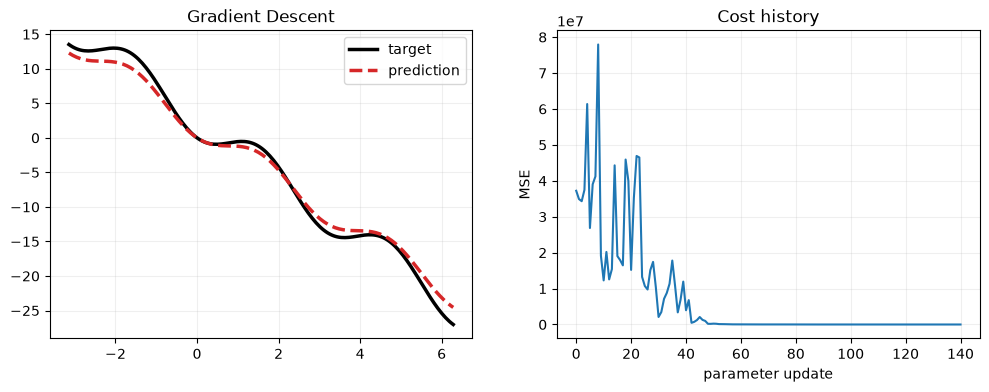

number of updates: 140
target params: [ 5.3 -4.3]
learned params: [ 3.79213313 -3.90570189]


In [15]:
initial_params = np.array([-10000, 4.0])

param_history, learned_model = train_with_batches(
    initial_params,
    get_function,
    dataset,
    grad,
    learning_rate=0.1,
    epochs=20,
    batch_size=32,
)

losses = plot_learning_result(
    param_history, dataset, target_function, "Gradient Descent"
)
print("number of updates:", len(param_history) - 1)
print("target params:", target_params)
print("learned params:", np.asarray(param_history)[-1])

## Q9. Learning rate 실험

실행하기 전에 learning rate가 너무 작거나 너무 클 때 cost가 어떻게 달라질지 먼저 예측해주세요.  
Mini-batch의 Gradient는 batch마다 조금씩 다르기 때문에, 전체 데이터에서 측정한 cost가 매 update마다 항상 감소하지는 않을 수 있습니다.  
개별 값보다 전체적인 감소 추세와 발산 여부를 관찰하세요.  
예측해보고, [실습 파일](./optimizer_practice.html) 로 확인도 해봅시다.

**>>> 너무 작을 경우에는 cost가 잘 줄어들지 않아 학습이 잘 되지 않고 느릴 것이며, 너무 클 경우에는 가중치가 너무 많이 움직여서 최적점을 지나칠 수 있음. 진동하거나 발산할 수 있음. <<<**

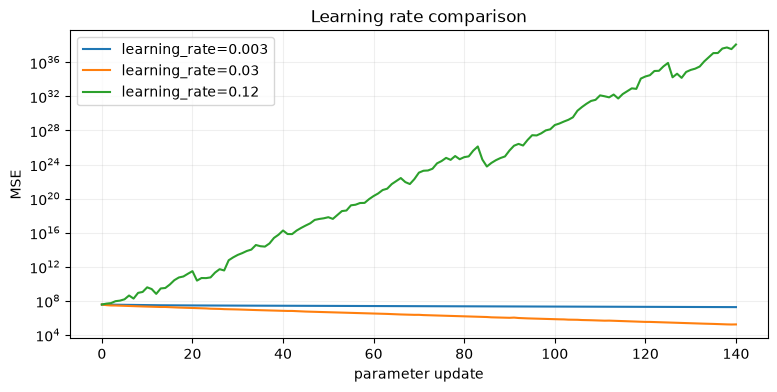

In [16]:
# learning rate 이외의 조건은 동일하게 유지합니다.
# batch 가 무작위로 결정되기 때문에 결과가 완전히 동일하진 않을 수도 있습니다.

learning_rates = [0.003, 0.03, 0.12]
learning_rate_results = {}

for rate in learning_rates:
    history, _ = train_with_batches(
        initial_params,
        get_function,
        dataset,
        grad,
        learning_rate=rate,
        epochs=20,
        batch_size=32,
    )
    learning_rate_results[rate] = {
        "history": np.asarray(history),
        "losses": losses_from_history(history, dataset),
    }

plt.figure(figsize=(9, 4))
for rate, result in learning_rate_results.items():
    plt.plot(result["losses"], label=f"learning_rate={rate}")

plt.xlabel("parameter update")
plt.ylabel("MSE")
plt.title("Learning rate comparison")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

**실제 결과는 예상과 같았나요?**  
각 learning rate에서 cost의 전체적인 감소 속도와 진동 또는 발산 여부를 비교하고,  
이 문제에서 적절하다고 생각한 값을 하나 선택해 이유를 적어주세요.  

**>>> 작은 경우 속도가 느렸고, 큰 경우 cost가 증가하며 발산함. 옵션 중 0.03이 빠르고 안정적으로 cost가 감소하여 적절함. <<<**

<a id="section-4-fashion-mnist"></a>
# 4. Fashion-MNIST에서 Optimizer 사용하기

데이터 전처리와 기본 신경망은 [1주차 과제](../week1/week1.ipynb)에서 이미 다뤘습니다.  
여기서는 같은 내용을 다시 구현하지 않고, **Gradient Descent에 따라 가중치를 구체적으로 조정하는 방법**인 optimizer를 1주차 모델에 연결하고 optimizer 별 핵심 개념을 확인합니다.

In [17]:
# 1주차와 같은 데이터 전처리와 기본 모델입니다. 제공된 코드를 사용합니다.
# 1주차와 달리 은닉층을 설정하기 위해 Dense Layer 가 추가되었습니다.

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.astype("float32") / 255.0
test_scaled = test_input.astype("float32") / 255.0

def build_fashion_model():
    return keras.Sequential([
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ])

## Q10. Optimizer의 이동 방식 비교하기

다음 optimizer가 Gradient Descent에 따른 가중치의 이동을 구체적으로 어떻게 조정하는지 정리해주세요.  
모든 내부 수식을 유도할 필요는 없습니다.

* SGD
* SGD + Momentum
* RMSprop
* Adam

단순히 “Adam이 더 좋다”라고 결론내리기보단, 각 Optimizer 가 어떤 개념을 가지고 있는지 정리해주세요.

자세한 내용은 다음을 참고해보세요.  
https://angeloyeo.github.io/2020/09/26/gradient_descent_with_momentum.html

**>>> 
SGD : 현재 gradient만 본다
SGD + Momentum : 과거 방향을 기억 -> 진동을 감소하고 진행방향으로는 가속한다
RMSprop : gradient의 방향을 누적하는 게 아닌 제곱을 누적한다 -> 계산식에 따라 gradient가 계속 큰 파라미터는 조심스러워지고, 작은 파라미터는 상대적으로 더 크게 움직인다
Adam : Momentum + RMSprop -> 방향, 크기 둘 다 기억, 둘의 장점을 합함
 <<<**

아래 코드를 실행시켜 직접 적용해봅시다.  
`selected_optimizer = optimizer_examples["Adam"]` 를 수정하여 다양한 Optimizer 를 사용해볼 수 있습니다.  
코드 작성을 하진 않지만, 어떤 코드인지는 이해해보고, 간략하게 흐름을 정리해주세요.

**>>> 
SGD : 0.792
SGD + Momentum : 0.842
RMSprop : 0.855
Adam : 0.859<<<**

In [31]:
# Keras optimizer는 객체를 만든 뒤 model.compile에 전달합니다.
# 아래 값들은 학습으로 정해지는 weight가 아니라 사람이 설정하는 hyperparameter입니다.

optimizer_examples = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "SGD + Momentum": keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9,
    ),
    "RMSprop": keras.optimizers.RMSprop(
        learning_rate=0.001,
        rho=0.9,
    ),
    "Adam": keras.optimizers.Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
    ),
}

tf.keras.utils.set_random_seed(42)
fashion_model = build_fashion_model()
selected_optimizer = optimizer_examples["Adam"]

fashion_model.compile(
    optimizer=selected_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fashion_history = fashion_model.fit(
    train_scaled,
    train_target,
    validation_split=0.2,
    epochs=3,
    batch_size=128,
    verbose=1,
)

test_loss, test_accuracy = fashion_model.evaluate(
    test_scaled,
    test_target,
    verbose=0,
)
print("test accuracy:", test_accuracy)

Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - accuracy: 0.8038 - loss: 0.5733 - val_accuracy: 0.8457 - val_loss: 0.4429
Epoch 2/3
176/375 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - accuracy: 0.8510 - loss: 0.4285

E0000 00:00:1790562222.217140 6544257 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - accuracy: 0.8538 - loss: 0.4162 - val_accuracy: 0.8582 - val_loss: 0.4054
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - accuracy: 0.8675 - loss: 0.3748 - val_accuracy: 0.8662 - val_loss: 0.3786
test accuracy: 0.859499990940094


## Q11. Parameter와 hyperparameter 구분하기

모델의 weight나 bias처럼 학습 중 업데이트되는 가중치를 **parameter**라고 합니다  
반면 optimizer 종류, learning rate, momentum, `beta_1`, `beta_2`, batch size, epochs 처럼  
학습 전에 개발자가 정하는 모델 구조와 학습 방식의 설정값은 **hyperparameter** 입니다.

아래는 4번 초기의 Base Code 입니다. 이 코드와 위의 Optimizer 비교 코드에서,  
parameter 와 hyperparameter 를 구분해서 정리해주세요.  

```python
def build_fashion_model():
    return keras.Sequential([
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
```

SGD + Momentum 에는 아래의 2개의 입력이 존재합니다.  
이 값이 변하면 어떻게 될지 예측해주세요.
* learning_rate
* momentum

ex) Cost Function 에 Local Minimum 이 많을 때, momentum 값이 커진다면 어떻게 될까요? 반대로 Local Minimum 이 적다면?  
learning_rate 는 어떻게 될까요?

**>>> 
각 dense layer의 W, b가 parameter이고, learning_rate, momentum이 hyperparameter이다
learning_rate가 너무 커지면 최적점을 지나치며 진동, 발산할 수 있고, 너무 적게 하면 학습속도가 느려진다.
momentum을 크게 하면 더 강한 관성을 가져 역시 최적점을 지나칠 수 있지만 local Minimum을 빠져나갈 가능성이 커질 수 있다.
local Minimum이 적고 비용함수가 단순하다면 꼭 momentum이 필요하지 않을 수 있고, 그냥 SGD를 사용할 수도 있다.
 <<<**

<a id="section-5-keras"></a>
# 5. Keras가 학습을 처리하는 방식

앞에서는 제공된 **grad**로 기울기를 구하고, 직접 작성한 **update**로 가중치를 바꿨습니다.  
Fashion-MNIST에서는 `compile`에 loss와 optimizer를 지정하고 `fit`으로 학습했습니다.  
Keras는 학습 가능한 가중치를 추적하고, TensorFlow의 자동미분으로 gradient를 구한 뒤 optimizer를 통해 업데이트합니다.  

Q12에서는 이 역할을 정리합니다. 이후 **Q13~Q14는 선택 실습**입니다. 같은 함수 $f_{a,b}(x)=a\sin^2(x)+bx$를 직접 Keras Layer로 만들고 싶은 경우 진행해주세요.  
건너뛰어도 필수 과정은 완료됩니다.

**Q12. Keras Layer의 build와 call은 각각 어떤 역할을 하나요?**  
일반 Python 숫자가 아니라 **add_weight**로 $a,b$를 만들어야 하는 이유도 함께 적어주세요.

**>>> build()는 학습에 필요한 파라미터를 생성한다. add_weight()를 이용하여 생성
call()은 실제 입력값이 들어왔을 때 파라미터를 이용하여 출력값을 계산한다.
a, b를 일반 python 숫자로 만들지 않고 add_weight()를 사용하는 이유는 Keras가 학습가능한 파라미터로 등록하고 추적할 수 있게 하기 위함이다.<<<**

앞에서는 Cost Function과 update를 구현하고 gradient 계산 함수를 연결했습니다.  
**여기부터 Q14까지는 선택 실습입니다.** Q13의 Layer를 완성한 뒤 채점과 학습 셀을 실행해주세요.  
Keras에서도 같은 함수를 학습시키기 위해, $a,b$를 학습 가능한 가중치로 등록해봅시다.

## Q13. SinLinearLayer 구현하기

요구사항:

- 입력 shape: $(batch,\ 1)$
- 출력 shape: 입력과 동일
- 학습 가능한 scalar weight 두 개: $a,b$
- **call**에서 $a\sin^2(x)+bx$ 계산

HINT
* scalar weight의 shape은 빈 tuple `()` 로 지정할 수 있습니다.  
* Tensorflow 에는 학습가능한 가중치와 학습불가능한 가중치라는 개념이 존재합니다.

레이어 만들기 참조자료: https://www.tensorflow.org/guide/keras/custom_layers_and_models?hl=ko

In [33]:
class SinLinearLayer(keras.layers.Layer):
    def build(self, input_shape):
        # TODO: self.add_weight를 사용해 학습 가능한 scalar a, b를 만드세요.
        self.a = self.add_weight(
            name = "a",
            shape = (),
            trainable = True
        )
        self.b = self.add_weight(
            name = "b",
            shape = (),
            trainable = True
        )

    def call(self, inputs):
        # TODO: TensorFlow 연산으로 a * sin(inputs)^2 + b * inputs를 반환하세요.
        return self.a * tf.sin(inputs) ** 2 + self.b * inputs

### 채점머신

In [34]:
def check_sin_linear_layer():
    layer = SinLinearLayer()
    test_x = tf.constant([[-1.0], [0.0], [1.0]], dtype=tf.float32)

    _ = layer(test_x)  # build 실행
    assert len(layer.trainable_weights) == 2, \
        "학습 가능한 weight a, b가 필요합니다."

    layer.a.assign(2.0)
    layer.b.assign(-1.0)

    actual = layer(test_x)
    expected = 2.0 * tf.sin(test_x) ** 2 - test_x

    assert actual.shape == test_x.shape, \
        f"출력 shape은 {test_x.shape}이어야 하지만 {actual.shape}입니다."
    assert np.allclose(actual.numpy(), expected.numpy()), \
        f"예상값은 {expected.numpy().ravel()}이지만 실제값은 {actual.numpy().ravel()}입니다."

try:
    check_sin_linear_layer()
    print("🎉 SinLinearLayer 정답입니다!")
except (AssertionError, TypeError, AttributeError) as error:
    print(error)

🎉 SinLinearLayer 정답입니다!


target a, b: [ 5.3 -4.3]
learned a, b: 5.029346 -4.278046


E0000 00:00:1790563380.509723 6544257 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


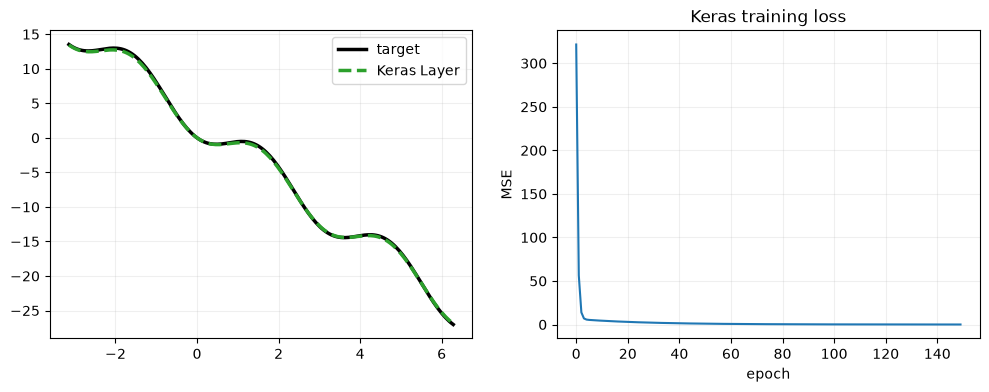

In [35]:
# 직접 만든 Layer를 실제로 학습시켜봅니다.

tf.keras.utils.set_random_seed(42)

layer_model = keras.Sequential([
    keras.Input(shape=(1,)),
    SinLinearLayer(), # 여러분이 구현한 Layer!
])

layer_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.03),
    loss="mse",
)

layer_history = layer_model.fit(
    xs.astype("float32").reshape(-1, 1),
    ys.astype("float32").reshape(-1, 1),
    epochs=150,
    batch_size=len(xs),
    verbose=0,
)

learned_layer = layer_model.layers[0]
print("target a, b:", target_params)
print("learned a, b:", learned_layer.a.numpy(), learned_layer.b.numpy())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(xs, ys, color="black", linewidth=2.5, label="target")
plt.plot(
    xs,
    layer_model.predict(xs.reshape(-1, 1), verbose=0).ravel(),
    color="tab:green",
    linestyle="--",
    linewidth=2.5,
    label="Keras Layer",
)
plt.legend()
plt.grid(alpha=0.2)

plt.subplot(1, 2, 2)
plt.plot(layer_history.history["loss"])
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Keras training loss")
plt.grid(alpha=0.2)

plt.show()

**선택 Q14. 직접 구현한 update와 Keras Layer 학습을 비교해주세요.**

- Keras 코드에서는 grad 함수가 보이지 않는데 gradient는 어디서 계산되나요?
- compile에 전달한 optimizer는 직접 구현한 update의 어느 부분을 담당하나요?

**>>> 
Kears 코드에서는 fit()이 학습을 수행할 때 자동으로 미분하여 gradient를 계산
compile에 전달한 optimizer는 직접 구현한 update에서 gradient를 이용해 파라미터를 갱신하는 부분을 담당 <<<**

# 정리

이번 필수 과정에서는 다음 흐름을 다뤘습니다.

1. 그림에서 손실의 기울기를 보고 가중치의 이동 방향 판단하기
2. 제공된 gradient로 가중치를 업데이트하고 batch 단위로 반복하기
3. learning rate에 따른 손실 변화 관찰하기
4. Fashion-MNIST에서 optimizer와 hyperparameter 연결하기
5. Keras가 gradient 계산과 업데이트를 맡는 역할 이해하기

핵심은 **예측 → 오차 확인 → 가중치 조절 → 반복**입니다.  
Gradient가 어디서 나오는지 더 알아보고 싶다면 아래 선택 심화과제를 진행해주세요. 본문을 먼저 마친 뒤 나중에 돌아와도 됩니다.  

여기까지 고생 많으셨습니다!

<a id="advanced"></a>
# 선택 심화과제: 편미분과 역전파로 Gradient 직접 구하기

**필수 제출 범위가 아닙니다.** 본문의 Q6까지 실행해 모델, 데이터, `cost_func`가 준비된 상태에서 진행해주세요. Q13의 Keras Layer 구현은 필요하지 않습니다.  
여기서는 제공된 `grad`가 어떻게 만들어졌는지 알아봅니다. 편미분 → Chain Rule → 계산 그래프 → 직접 구현 순서입니다.  

역전파는 중간 계산 결과를 재사용해 gradient를 효율적으로 구합니다. 계산 그래프를 보며 어떤 값이 재사용되는지도 생각해보세요.

<a id="advanced-a"></a>
## 심화 A. 미분에서 편미분으로

미분은 입력을 아주 조금 바꾸었을 때 출력이 얼마나 변하는지를 나타냅니다.  
입력이 여러 개인 경우에 한 번에 하나만 움직이고 나머지는 고정해서 변화를 살펴볼 수 있습니다. 이러한 개념을 **편미분(partial derivative)** 이라고 합니다.

예를 들어 $z=a^2+3b$에서는

$$
\frac{\partial z}{\partial a}=2a,
\qquad
\frac{\partial z}{\partial b}=3
$$

입니다. $a$로 편미분할 때는 $b$를 상수로, $b$로 편미분할 때는 $a$를 상수로 취급합니다.  
기호 $\partial z/\partial a$는 분수가 아니라 **$a$의 변화에 대한 $z$의 변화율**을 나타내는 하나의 표현입니다.

본문에서는 다음의 모델을 다뤘습니다.

$$
\hat y_i=a\sin^2(x_i)+bx_i
$$

학습 중에는 데이터 $x_i,y_i$는 고정되어 있고, 학습이 진행됨에 따라 parameter $a,b$만 변하게 됩니다. 따라서

$$
\frac{\partial \hat y_i}{\partial a}=\sin^2(x_i),
\qquad
\frac{\partial \hat y_i}{\partial b}=x_i
$$

입니다. 예를 들어 $a$만 아주 조금 증가시키면 예측값은 대략 $\sin^2(x_i)$에 비례해 변합니다.

### 모델의 미분과 Cost Function의 미분 연결하기

**편미분에 대한 명확한 이해가 없다면, 모두 정확하게 확인하기 어려울 수 있습니다.**  
**처음에는 Cost Function 에서 각 가중치까지 편미분을 통해 전달되며, 이는 Chain Rule 을 통해서 순차적으로 흐른다는 점만 인식하면 됩니다.**


데이터 하나의 오차와 전체 MSE를 다음처럼 나누어 적어봅시다.

$$
e_i=\hat y_i-y_i,
\qquad \ell_i=e_i^2,
\qquad L=\frac{1}{N}\sum_{i=1}^{N}\ell_i
$$

먼저 예측값 $\hat y_i$가 Cost Function에 미치는 영향은

$$
\frac{\partial L}{\partial \hat y_i} 
= \frac{\partial L}{\partial \ell_i} \times \frac{\partial \ell_i}{\partial e_i} \times \frac{\partial e_i}{\partial \hat y_i}
= \frac{1}{N} \times 2(\hat y_i-y_i) \times 1
$$

입니다. 우리가 원하는 것은 예측값이 아니라 parameter에 대한 Cost Function 값의 변화량입니다.  
**Chain rule**을 사용하면 중간 변화율을 곱해서 연결할 수 있습니다.

$$
\frac{\partial L}{\partial a}
=\sum_{i=1}^{N}
\frac{\partial L}{\partial \hat y_i}
\frac{\partial \hat y_i}{\partial a}
=\frac{2}{N}\sum_{i=1}^{N}(\hat y_i-y_i)\sin^2(x_i)
$$

$$
\frac{\partial L}{\partial b}
=\sum_{i=1}^{N}
\frac{\partial L}{\partial \hat y_i}
\frac{\partial \hat y_i}{\partial b}
=\frac{2}{N}\sum_{i=1}^{N}(\hat y_i-y_i)x_i
$$

각 데이터가 같은 $a,b$를 함께 사용하므로 데이터별 기여를 마지막에 모두 더합니다. 이 합은 코드에서 두 벡터의 **내적**으로 표현할 수 있습니다.

<a id="advanced-b"></a>
## 심화 B. 계산 그래프와 역전파

계산 그래프(computational graph)는 하나의 긴 수식을 작은 연산으로 나누어 나타낸 것입니다.  
<img src="./imgs/forward_backward.png" width=800 >

- **Forward pass(순전파)**: 왼쪽에서 오른쪽으로 값을 계산해 예측값과 Cost Function 값을 구합니다.
- **Backward pass(역전파)**: 오른쪽의 Cost Function에서 시작해, 각 값이 Cost Function에 준 영향인 Gradient를 반대 방향으로 전달합니다.

신경망도 원리는 같습니다. 층과 parameter가 많아져 계산 그래프가 길어질 뿐, 순전파로 중간값을 계산하고 Back Propagation으로 Gradient를 전달합니다.

이번 모델과 MSE에서 데이터 하나가 지나가는 경로는 다음과 같습니다.  
<img src="./imgs/graph.png" width=400 >

### 계산 그래프를 뒤로 따라가기

역전파는 최종 출력인 Cost Function에서 $\partial L/\partial L=1$로 시작합니다.  
역전파의 흐름은 다음처럼 정리할 수 있습니다.

$$
\frac{\partial L}{\partial L}=1
\quad\xrightarrow{\text{Back Propagation}}\quad
\left(\frac{\partial L}{\partial a},\frac{\partial L}{\partial b}\right)
$$

이번 예시에서는 Layer 가 상대적으로 적기 때문에 장점과 연산이 뚜렷하게 보이진 않습니다.  
구체적인 예시를 살펴보고 싶다면 다음의 링크를 참조해주세요.  
https://wikidocs.net/434867

Back Propagation은 parameter를 직접 업데이트하는 방법이 아닙니다.  
**Back Propagation은 각 parameter에 대한 Gradient를 효율적으로 계산하고**  
**Gradient Descent 또는 optimizer는 그 Gradient를 사용해 parameter를 업데이트합니다.**

<a id="advanced-c"></a>
## 심화 C. Gradient 구현하기

먼저 출력값에 대한 MSE의 gradient는 다음과 같습니다.

$$
\frac{\partial L}{\partial \hat{\mathbf y}}
=\frac{2}{N}(\hat{\mathbf y}-\mathbf y)
$$

모델의 각 parameter에 대한 출력의 미분은 다음과 같습니다.

$$
\frac{\partial \hat y_i}{\partial a}=\sin^2(x_i),
\qquad
\frac{\partial \hat y_i}{\partial b}=x_i
$$

따라서 각 데이터가 parameter에 미치는 영향을 모두 더해 $\partial L/\partial a$, $\partial L/\partial b$를 구할 수 있습니다.

힌트:

- 두 벡터의 내적은 **np.dot(vector1, vector2)** 로 계산할 수 있습니다.
- 반환 순서는 반드시 $[\,\partial L/\partial a,\ \partial L/\partial b\,]$입니다.

본문의 제공 함수와 구분하기 위해 `grad_advanced`라는 이름으로 구현합니다. 아래 수치미분 채점으로 검증해주세요.

자세한 내용은 다음을 참고해보세요.  
https://angeloyeo.github.io/2019/08/25/gradient.html

In [36]:
def grad_advanced(xs, ys, y_preds):
    """
    xs: 입력 ex) np.array([])
    ys: 정답
    y_preds: 모델 예측값

    [dL/da, dL/db]를 NumPy 배열로 반환합니다.
    """
    assert len(xs) == len(ys) == len(y_preds)

    # TODO: dL/dout을 계산하세요.
    dL_dout = (2 / len(xs)) * (y_preds - ys)

    # TODO: chain rule을 사용해 두 parameter의 gradient를 계산하세요.
    grad_a = np.dot(dL_dout, np.sin(xs)**2)
    grad_b = np.dot(dL_dout, xs)

    return np.array([grad_a, grad_b], dtype=np.float64)

### 수치미분을 이용한 채점머신
위의 함수를 구현한 다음에 아래 코드를 다시 실행해주세요.  
다시 실행하면 채점결과가 나옵니다. 틀린 경우, 어떤 예제에서 틀렸는지 알려줍니다.  
**아래의 코드를 이해할 필요는 전혀!!!! 없습니다!**

하지만...  
**Q. 미니문제(필수 아님)**  
대략적으로 아래 코드는 직접 구현한 gradient와 아주 작은 parameter 변화로 계산한 수치미분을 비교합니다.  
코드를 구체적으로 이해하진 않더라도 아래의 `numerical_grad` 가 어떤 연산을 할지 예측해보세요.

**>>> 아주 작은값을 더한값과 뺀값을 그것의 2배로 나눠 미분을 근사함 <<<**

In [37]:
def numerical_grad(params, xs, ys, epsilon=1e-6):
    result = np.zeros_like(params, dtype=np.float64)

    for index in range(len(params)):
        plus = params.copy()
        minus = params.copy()
        plus[index] += epsilon
        minus[index] -= epsilon

        plus_cost = cost_func(get_function(*plus)(xs), ys)
        minus_cost = cost_func(get_function(*minus)(xs), ys)
        result[index] = (plus_cost - minus_cost) / (2 * epsilon)

    return result

def check_grad_advanced():
    params_test = np.array([1.7, -0.8])
    predictions_test = get_function(*params_test)(xs)

    analytic = grad_advanced(xs, ys, predictions_test)
    numeric = numerical_grad(params_test, xs, ys)

    assert analytic.shape == (2,), f"gradient shape은 (2,)여야 하지만 {analytic.shape}입니다."
    assert np.allclose(analytic, numeric, atol=1e-5), \
        f"직접 구현한 gradient {analytic}와 수치미분 {numeric}이 다릅니다."

try:
    check_grad_advanced()
    print("🎉 grad_advanced 정답입니다!")
except (AssertionError, TypeError, ValueError) as error:
    print(error)

🎉 grad_advanced 정답입니다!
